In [23]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import os
import pandas as pd
from datetime import timedelta
import matplotlib.dates as mdates
import matplotlib as mpl

In [2]:
PATH_CLASS = './../data/classification/'
PATH_FIG = '../figures/'

In [3]:
# Reading all netcdf files of cloudnet classification products 
cloudnet_filename = []
for file in os.listdir(PATH_CLASS):
    if file.endswith(".nc"):
        cloudnet_filename.append(file)

## Display netCDf content of one file 

### General information

In [4]:
test = nc.Dataset(PATH_CLASS+cloudnet_filename[0])
print(test)

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    Conventions: CF-1.8
    cloudnetpy_version: 1.31.0
    file_uuid: e5b13dd1-50d4-4deb-8efd-b7fff5bfcf43
    cloudnet_file_type: classification
    title: Classification products from Granada
    source_file_uuids: 848204b8-b351-45a0-968b-3a086c0e5fe6
    location: Granada
    day: 28
    month: 04
    year: 2021
    source: RPG-Radiometer Physics RPG-FMCW-94
Lufft CHM15k
RPG-Radiometer Physics HATPRO
ECMWF Integrated Forecast System (IFS)
    history: 2022-03-18 18:14:23 +00:00 - classification file created
2022-03-18 18:14:10 +00:00 - categorize file created
2022-03-18 14:19:40 +00:00 - mwr file created
2022-02-15 17:25:05 +00:00 - radar file created
2022-02-08 10:51:03 +00:00 - NetCDF generated from original data by CLU using cnmodel2nc on legacy-cloudnet.fmi.fi
2021-11-16 18:17:39 +00:00 - lidar file created
    references: https://doi.org/10.21105/joss.02123
    dimensions(sizes): time(

### Show netCDF variables and dimensions

In [5]:
test.variables

{'target_classification': <class 'netCDF4._netCDF4.Variable'>
 int32 target_classification(time, height)
     _FillValue: -2147483647
     units: 1
     long_name: Target classification
     comment: This variable provides the main atmospheric target classifications
 that can be distinguished by radar and lidar.
     definition: 
 Value 0: Clear sky.
 Value 1: Cloud liquid droplets only.
 Value 2: Drizzle or rain.
 Value 3: Drizzle or rain coexisting with cloud liquid droplets.
 Value 4: Ice particles.
 Value 5: Ice coexisting with supercooled liquid droplets.
 Value 6: Melting ice particles.
 Value 7: Melting ice particles coexisting with cloud liquid droplets.
 Value 8: Aerosol particles, no cloud or precipitation.
 Value 9: Insects, no cloud or precipitation.
 Value 10: Aerosol coexisting with insects, no cloud or precipitation.
 unlimited dimensions: 
 current shape = (2880, 380)
 filling on,
 'detection_status': <class 'netCDF4._netCDF4.Variable'>
 int32 detection_status(time, hei

In [6]:
# check if 2 and 3 could exist togheter
sum_liquid = np.sum(test.variables['target_classification'][:] == 1, axis=1)
sum_drizzle_or_rain = np.sum(test.variables['target_classification'][:] == 2, axis=1)
sum_drizzle_or_rain_with_cloud_liquid = np.sum(test.variables['target_classification'][:] == 3, axis=1)

for i in range(sum_liquid.shape[0]): #time
    if sum_liquid[i] != 0 and sum_drizzle_or_rain[i] !=0 and sum_drizzle_or_rain_with_cloud_liquid[i] !=0:
        print("liquid = %d, dry_rain = %d, dry_rain_cloud = %d"%(sum_liquid[i], sum_drizzle_or_rain[i], sum_drizzle_or_rain_with_cloud_liquid[i]))

liquid = 5, dri_rain = 4, dri_rain_cloud = 4
liquid = 4, dri_rain = 4, dri_rain_cloud = 5
liquid = 3, dri_rain = 3, dri_rain_cloud = 4
liquid = 12, dri_rain = 7, dri_rain_cloud = 1
liquid = 2, dri_rain = 11, dri_rain_cloud = 5
liquid = 2, dri_rain = 10, dri_rain_cloud = 8
liquid = 3, dri_rain = 12, dri_rain_cloud = 7
liquid = 3, dri_rain = 3, dri_rain_cloud = 19
liquid = 4, dri_rain = 7, dri_rain_cloud = 18
liquid = 18, dri_rain = 3, dri_rain_cloud = 25
liquid = 1, dri_rain = 2, dri_rain_cloud = 4
liquid = 1, dri_rain = 4, dri_rain_cloud = 10
liquid = 2, dri_rain = 2, dri_rain_cloud = 12
liquid = 11, dri_rain = 10, dri_rain_cloud = 7
liquid = 1, dri_rain = 8, dri_rain_cloud = 5
liquid = 1, dri_rain = 5, dri_rain_cloud = 5
liquid = 2, dri_rain = 4, dri_rain_cloud = 3
liquid = 3, dri_rain = 4, dri_rain_cloud = 2
liquid = 2, dri_rain = 19, dri_rain_cloud = 1
liquid = 6, dri_rain = 32, dri_rain_cloud = 10
liquid = 1, dri_rain = 9, dri_rain_cloud = 2
liquid = 2, dri_rain = 9, dri_rain_cloud

In [7]:
nfiles        = len(cloudnet_filename)
nliquid_cloud = []
dtime         = []
for i, file in enumerate(cloudnet_filename):
    print("Read = %d / %d"%(i+1, nfiles))
    classification = nc.Dataset(PATH_CLASS+file)

    aux_t = []
    for h in classification['time']:
        aux_t.append( file[:8] + ' ' + str(timedelta(hours=float(h))) )

    dtime.append( pd.to_datetime(aux_t, format = "%Y%m%d %H:%M:%S") )

    nheight = classification.dimensions['height'].size
    ntime   = classification.dimensions['time'].size

    liquid_cloud                      = 1 # set the value concerning liquid clouds
    drizzle_or_rain                   = 2
    drizzle_or_rain_with_cloud_liquid = 3
    case_day                          = np.zeros(ntime)
    for j in range(ntime):
        if liquid_cloud in classification.variables['target_classification'][j,:]\
        and drizzle_or_rain not in classification.variables['target_classification'][j,:]\
        and drizzle_or_rain_with_cloud_liquid not in classification.variables['target_classification'][j,:]:
            case_day[j] = 1
    
    nliquid_cloud.append(case_day.sum()/ntime)

Read = 1 / 30
Read = 2 / 30
Read = 3 / 30
Read = 4 / 30
Read = 5 / 30
Read = 6 / 30
Read = 7 / 30
Read = 8 / 30
Read = 9 / 30
Read = 10 / 30
Read = 11 / 30
Read = 12 / 30
Read = 13 / 30
Read = 14 / 30
Read = 15 / 30
Read = 16 / 30
Read = 17 / 30
Read = 18 / 30
Read = 19 / 30
Read = 20 / 30
Read = 21 / 30
Read = 22 / 30
Read = 23 / 30
Read = 24 / 30
Read = 25 / 30
Read = 26 / 30
Read = 27 / 30
Read = 28 / 30
Read = 29 / 30
Read = 30 / 30


In [8]:
dic_time_day = {}
for i, time in enumerate(dtime):
    dic_time_day[time.day[0]] = nliquid_cloud[i]

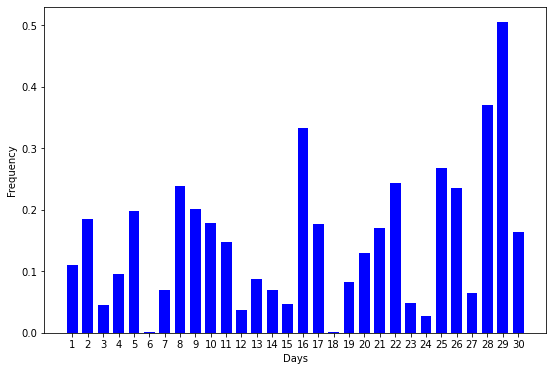

In [13]:
sdate = min(dic_time_day.keys())
edate = max(dic_time_day.keys())
fig   = plt.figure(figsize=[9, 6])
axs   = plt.subplot()
hist  = plt.bar(dic_time_day.keys(), dic_time_day.values(), width=.7, color='b')

axs.set_ylabel(r'Frequency')
axs.set_xlabel(r'Days')
axs.set_xticks( np.arange(sdate, edate+1) )
#axs.set_yscale('log')
plt.show()

In [24]:
mpl.rcParams.update({'font.size': 24})

In [15]:
dic_database = {}
dic_database[2018] = np.count_nonzero(np.array([4, 6, 7, 8, 9, 10, 11]))
dic_database[2019] = np.count_nonzero(np.array([3, 4, 5, 6, 7, 9, 10, 11, 12]))
dic_database[2020] = np.count_nonzero(np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]))
dic_database[2021] = np.count_nonzero(np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]))
dic_database[2022] = np.count_nonzero(np.array([11, 12]))
dic_database[2023] = np.count_nonzero(np.array([1, 2, 3, 4, 5, 6]))

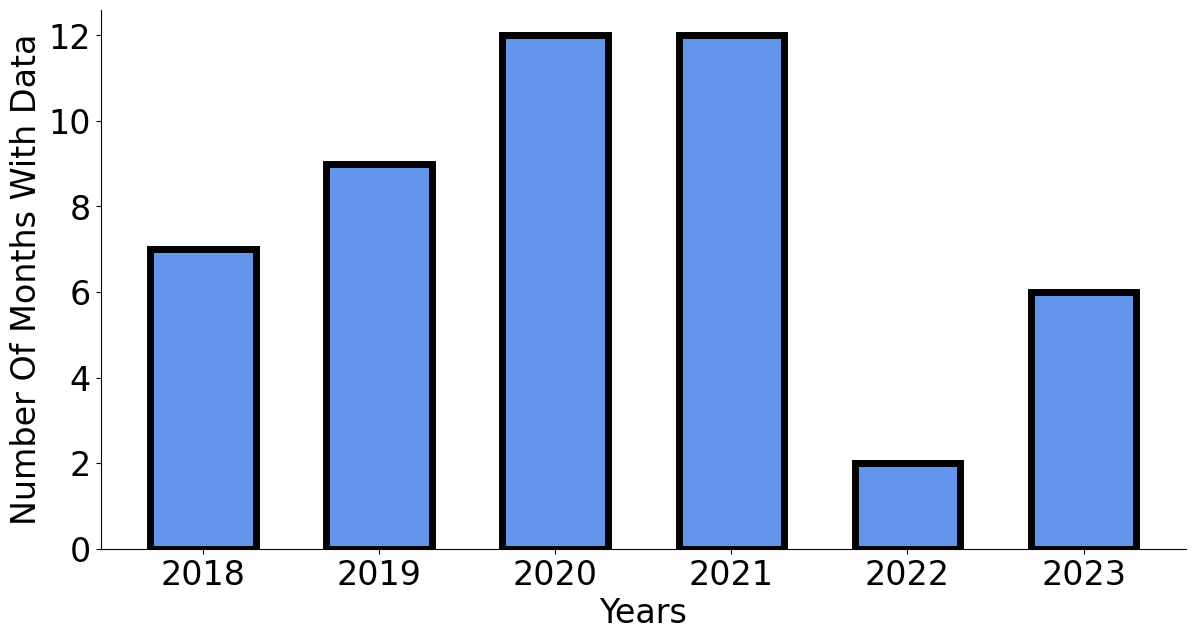

In [66]:
sdate = min(dic_database.keys())
edate = max(dic_database.keys())

fig   = plt.figure(figsize=[14, 7])
axs   = plt.subplot()
hist  = plt.bar(dic_database.keys(), dic_database.values(), color='cornflowerblue', edgecolor='k', linewidth=5, width=.6)

# axs.set_title(r'Extensive database')
# axs.set_ylabel(r'$\sum$ (month with data)')
axs.set_ylabel(r'Number Of Months With Data')
axs.set_xlabel(r'Years')
axs.set_xticks( np.arange(sdate, edate+1) )
axs.set_yticks( np.arange(0, 13,2) )
axs.spines[['right', 'top']].set_visible(False)
plt.savefig(PATH_FIG+'database.png', dpi=400)
plt.show()